### Titanic Classification - with Ensemble ###

Purpose: Inspired by the Kaggle Titanic Competition and wanting to learn about multi-model 'ensembles', I set to work trying to beat my own top classification accuracy score of ~81% on Titanic classification (seriously, that should get its own class in SciKit Learn! {side note, if you "got" that joke, you are as big a nerd as I am - and that is a compliment! ;) })

In [1]:
# Import required libraries:

import pandas as pd
import numpy as np
from sklearn.model_selection import ( 
    train_test_split, GridSearchCV
)

from sklearn.ensemble import (
    RandomForestClassifier
    , GradientBoostingClassifier
    , VotingClassifier
    , HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score
    , classification_report
    , confusion_matrix
    , ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import warnings 
warnings.simplefilter('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# Load the Titanic dataset
df = pd.read_csv('../data/titanic_data/train.csv')

df.shape
df.head(3)
df.info()

(891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Preprocess the dataset (set up as a function bc I've preprocessing the darn dataset so many times already!)

def preprocess_data(df):
    # Fill missing values
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)

    # Convert categorical features to numeric
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

    # Drop irrelevant columns
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    return df

# Preprocess the data
df = preprocess_data(df)

In [4]:
df.shape
df.head(3)
df.info()

(891, 8)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [5]:
# Separate features and target variable
X = df.drop('Survived', axis=1)
y = df['Survived']

X.shape, y.shape

((891, 7), (891,))

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
    , random_state=27
)

# Display the shapes of the training and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [7]:
# Initialize ensemble models (*Note: Since these are all tree methods, we did NOT standardize;)

# ALSO note: since we are building out a grid for params, we dont need to include any in here, aside fm random_state and the mando params for XGB;

rf_model = RandomForestClassifier(
    random_state=27
)
gb_model = GradientBoostingClassifier(
    random_state=27
)
xgb_model = XGBClassifier(
    use_label_encoder=False, eval_metric='logloss', random_state=27
)

hgb_model = HistGradientBoostingClassifier(
    random_state=27
)

In [8]:
# Define parameter grids for each model:

rf_param_grid = {
    'n_estimators': [100, 200, 500]
    , 'max_depth': [None, 10]
    , 'min_samples_split': [2, 5, 7]
    , 'min_samples_leaf': [1, 2, 3]
}

gb_param_grid = {
    'n_estimators': [100, 200, 500]
    , 'learning_rate': [0.05, 0.1]
    , 'max_depth': [3, 5, 7, 9]
}

xgb_param_grid = {
    'n_estimators': [100, 200, 500]
    , 'learning_rate': [0.05, 0.1]
    , 'max_depth': [3, 5, 7, 9]
}


hgb_param_grid = {
    'max_iter': [100, 200, 500]
    , 'min_samples_leaf': [10, 20, 30]
    , 'l2_regularization': np.logspace(-2, 2, 13)
    , 'max_depth': [3, 5, 7, 9]
}

In [9]:
# Perform Grid Search for each model:
%time

# Random Forest Grid Search
rf_grid_search = GridSearchCV(
    estimator=rf_model
    , param_grid=rf_param_grid
    , cv=5
    , scoring='accuracy'
    , n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

# Gradient Boosting Grid Search
gb_grid_search = GridSearchCV(
    estimator=gb_model
    , param_grid=gb_param_grid
    , cv=5
    , scoring='accuracy'
    , n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

# XGBoost Grid Search
xgb_grid_search = GridSearchCV(
    estimator=xgb_model
    , param_grid=xgb_param_grid
    , cv=5
    , scoring='accuracy'
    , n_jobs=-1
)

xgb_grid_search.fit(X_train, y_train)


# Use GridSearchCV to find fine-tune hyperparameters:
hgb_grid_search = GridSearchCV(
    estimator=hgb_model
    , param_grid=hgb_param_grid
    , cv=3
    , scoring='accuracy'
    , n_jobs=-1
)

hgb_grid_search.fit(X_train, y_train)

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 5.96 µs


,estimator,RandomForestC...ndom_state=27)
,param_grid,"{'max_depth': [None, 10], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


,estimator,GradientBoost...ndom_state=27)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


,estimator,HistGradientB...ndom_state=27)
,param_grid,"{'l2_regularization': array([1.0000...00000000e+02]), 'max_depth': [3, 5, ...], 'max_iter': [100, 200, ...], 'min_samples_leaf': [10, 20, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [11]:
best_rf_model = rf_grid_search.best_estimator_
print("Best Parameters for Random Forest:", rf_grid_search.best_params_)

best_gb_model = gb_grid_search.best_estimator_
print("\nBest Parameters for Gradient Boosting:", gb_grid_search.best_params_)

best_xgb_model = xgb_grid_search.best_estimator_
print("\nBest Parameters for XGBoost:", xgb_grid_search.best_params_)

best_hgb_model = hgb_grid_search.best_estimator_
print("\nBest Parameters for HGBoost:", hgb_grid_search.best_params_)

Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}

Best Parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best Parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 100}

Best Parameters for HGBoost: {'l2_regularization': 46.41588833612777, 'max_depth': 3, 'max_iter': 500, 'min_samples_leaf': 20}


In [12]:
# Voting Classifier (Ensemble of all FOUR models)

voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf_model)
        , ('gb', best_gb_model)
        , ('xgb', best_xgb_model)
        , ('hgb', best_hgb_model)
    ], voting='soft'
)
voting_model.fit(X_train, y_train)
voting_preds = voting_model.predict(X_test)

# Evaluate Voting Classifier
print("Voting Classifier Accuracy:", accuracy_score(y_test, voting_preds))

,estimators,"[('rf', ...), ('gb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2


Voting Classifier Accuracy: 0.8268156424581006


In [13]:
voting_model.estimators_

[RandomForestClassifier(min_samples_leaf=2, n_estimators=500, random_state=27),
 GradientBoostingClassifier(learning_rate=0.05, random_state=27),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=9, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, ...),
 HistGradientBoostingClassifier(l2_regularization=46.415888336127

In [14]:
print("Classification Report:\n")
print(classification_report(y_test, voting_preds))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, voting_preds))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       112
           1       0.80      0.72      0.76        67

    accuracy                           0.83       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179

Confusion Matrix:

[[100  12]
 [ 19  48]]


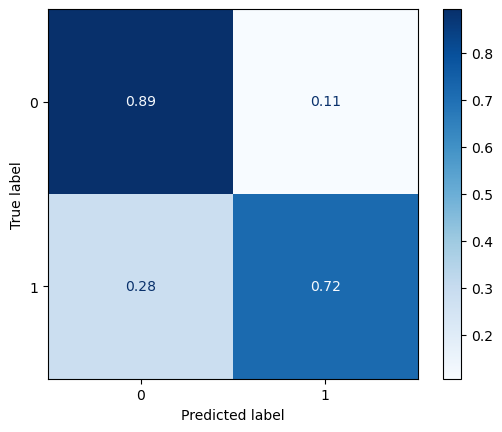

In [16]:
#Plot a confusion matrix:

ConfusionMatrixDisplay.from_predictions(
    y_test, voting_preds
    , normalize="true", cmap="Blues"
);